# **Austria GP 2026**
## Results and Lap Analysis

In [1]:
# Imports
import sys
import importlib
sys.path.append("../..")

import Sliplib.slipload as sl
import Sliplib.selection as slipclassify
import Sliplib.GridSum as grid_sum
import Sliplib.plotting as slplot

importlib.reload(slipclassify)
importlib.reload(grid_sum)

<module 'Sliplib.GridSum' from '/mnt/Windows/Projects_S1/ProjectSlipstream/2026_British_GP/notebooks/../../Sliplib/GridSum.py'>

In [2]:
# Load Session
session_Q = sl.load_gp(2025,"British Grand Prix","Q")
session_Q.load()

core           INFO 	Loading data for British Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '4', '63', '44', '16', '12', '87', '14', '10', '55', '22', '6', '23', '31', '30', '5', '18', '27', '43']


### Result Inspection
Inspect Results of Qualifying Sessions

In [3]:
# Import Session Result
ses_res = session_Q.results
ses_res

,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,Position,ClassifiedPosition,GridPosition,Q1,Q2,Q3,Time,Status,Points,Laps
1,1,M VERSTAPPEN,VER,max_verstappen,Red Bull Racing,4781D7,red_bull,Max,Verstappen,Max Verstappen,...,1.0,,NaN,0 days 00:01:25.886000,0 days 00:01:25.316000,0 days 00:01:24.892000,NaT,,NaN,NaN
81,81,O PIASTRI,PIA,piastri,McLaren,F47600,mclaren,Oscar,Piastri,Oscar Piastri,...,2.0,,NaN,0 days 00:01:25.963000,0 days 00:01:25.316000,0 days 00:01:24.995000,NaT,,NaN,NaN
4,4,L NORRIS,NOR,norris,McLaren,F47600,mclaren,Lando,Norris,Lando Norris,...,3.0,,NaN,0 days 00:01:26.123000,0 days 00:01:25.231000,0 days 00:01:25.010000,NaT,,NaN,NaN
63,63,G RUSSELL,RUS,russell,Mercedes,00D7B6,mercedes,George,Russell,George Russell,...,4.0,,NaN,0 days 00:01:26.236000,0 days 00:01:25.637000,0 days 00:01:25.029000,NaT,,NaN,NaN
44,44,L HAMILTON,HAM,hamilton,Ferrari,ED1131,ferrari,Lewis,Hamilton,Lewis Hamilton,...,5.0,,NaN,0 days 00:01:26.296000,0 days 00:01:25.084000,0 days 00:01:25.095000,NaT,,NaN,NaN
16,16,C LECLERC,LEC,leclerc,Ferrari,ED1131,ferrari,Charles,Leclerc,Charles Leclerc,...,6.0,,NaN,0 days 00:01:26.186000,0 days 00:01:25.133000,0 days 00:01:25.121000,NaT,,NaN,NaN
12,12,K ANTONELLI,ANT,antonelli,Mercedes,00D7B6,mercedes,Kimi,Antonelli,Kimi Antonelli,...,7.0,,NaN,0 days 00:01:26.265000,0 days 00:01:25.620000,0 days 00:01:25.374000,NaT,,NaN,NaN
87,87,O BEARMAN,BEA,bearman,Haas F1 Team,9C9FA2,haas,Oliver,Bearman,Oliver Bearman,...,8.0,,NaN,0 days 00:01:26.005000,0 days 00:01:25.534000,0 days 00:01:25.471000,NaT,,NaN,NaN
14,14,F ALONSO,ALO,alonso,Aston Martin,229971,aston_martin,Fernando,Alonso,Fernando Alonso,...,9.0,,NaN,0 days 00:01:26.108000,0 days 00:01:25.593000,0 days 00:01:25.621000,NaT,,NaN,NaN
10,10,P GASLY,GAS,gasly,Alpine,00A1E8,alpine,Pierre,Gasly,Pierre Gasly,...,10.0,,NaN,0 days 00:01:26.328000,0 days 00:01:25.711000,0 days 00:01:25.785000,NaT,,NaN,NaN


In [4]:
ses_res.columns

Index(['DriverNumber', 'BroadcastName', 'Abbreviation', 'DriverId', 'TeamName',
       'TeamColor', 'TeamId', 'FirstName', 'LastName', 'FullName',
       'HeadshotUrl', 'CountryCode', 'Position', 'ClassifiedPosition',
       'GridPosition', 'Q1', 'Q2', 'Q3', 'Time', 'Status', 'Points', 'Laps'],
      dtype='object')

In [5]:
# Display Clean Result
Q_result = slipclassify.clean_result_Quali(ses_res)
Q_result

,Abbreviation,TeamName,Position
1,VER,Red Bull Racing,1.0
81,PIA,McLaren,2.0
4,NOR,McLaren,3.0
63,RUS,Mercedes,4.0
44,HAM,Ferrari,5.0
16,LEC,Ferrari,6.0
12,ANT,Mercedes,7.0
87,BEA,Haas F1 Team,8.0
14,ALO,Aston Martin,9.0
10,GAS,Alpine,10.0


In [6]:
# Export Results of Quali
Q_result.to_csv("../data/Quali_Result.csv")

### Time Analysis

In [7]:
# Load lap data
Q_lap = session_Q.laps
Q_lap

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:18:20.889000,VER,1,NaT,1.0,1.0,0 days 00:16:37.294000,NaT,NaT,0 days 00:00:45.342000,...,True,Red Bull Racing,0 days 00:16:37.294000,2025-07-05 14:03:03.035,1,NaN,False,,False,False
1,0 days 00:19:46.930000,VER,1,0 days 00:01:26.041000,2.0,1.0,NaT,NaT,0 days 00:00:27.749000,0 days 00:00:34.530000,...,True,Red Bull Racing,0 days 00:18:20.889000,2025-07-05 14:04:46.630,1,NaN,False,,False,True
2,0 days 00:21:45.843000,VER,1,0 days 00:01:58.913000,3.0,1.0,NaT,0 days 00:21:38.744000,0 days 00:00:40.663000,0 days 00:00:47.489000,...,True,Red Bull Racing,0 days 00:19:46.930000,2025-07-05 14:06:12.671,1,NaN,False,,False,False
3,0 days 00:37:07.870000,VER,1,NaT,4.0,2.0,0 days 00:34:58.983000,NaT,NaT,0 days 00:00:42.578000,...,False,Red Bull Racing,0 days 00:34:58.983000,2025-07-05 14:21:24.724,1,NaN,False,,False,False
4,0 days 00:38:33.756000,VER,1,0 days 00:01:25.886000,5.0,2.0,NaT,NaT,0 days 00:00:27.836000,0 days 00:00:34.494000,...,False,Red Bull Racing,0 days 00:37:07.870000,2025-07-05 14:23:33.611,1,NaN,False,,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286,0 days 00:17:40.550000,COL,43,0 days 00:01:27.060000,2.0,1.0,NaT,NaT,0 days 00:00:28.281000,0 days 00:00:35.024000,...,True,Alpine,0 days 00:16:13.490000,2025-07-05 14:02:39.231,1,NaN,False,,False,True
287,0 days 00:19:44.715000,COL,43,0 days 00:02:04.165000,3.0,1.0,NaT,NaT,0 days 00:00:41.964000,0 days 00:00:50.547000,...,True,Alpine,0 days 00:17:40.550000,2025-07-05 14:04:06.291,1,NaN,False,,False,True
288,0 days 00:21:49.515000,COL,43,0 days 00:02:04.800000,4.0,1.0,NaT,NaT,0 days 00:00:44.085000,0 days 00:00:52.275000,...,True,Alpine,0 days 00:19:44.715000,2025-07-05 14:06:10.456,1,NaN,False,,False,True
289,0 days 00:23:43.678000,COL,43,0 days 00:01:54.163000,5.0,1.0,NaT,NaT,0 days 00:00:28.245000,0 days 00:00:35.029000,...,True,Alpine,0 days 00:21:49.515000,2025-07-05 14:08:15.256,12,NaN,False,,False,True


In [8]:
# Fastest Lap
fastest_lap = Q_lap.pick_fastest()
fastest_lap

Time                      0 days 01:24:27.741000
Driver                                       VER
DriverNumber                                   1
LapTime                   0 days 00:01:24.892000
LapNumber                                   17.0
Stint                                        6.0
PitOutTime                                   NaT
PitInTime                                    NaT
Sector1Time               0 days 00:00:27.493000
Sector2Time               0 days 00:00:33.973000
Sector3Time               0 days 00:00:23.426000
Sector1SessionTime        0 days 01:23:30.342000
Sector2SessionTime        0 days 01:24:04.315000
Sector3SessionTime        0 days 01:24:27.741000
SpeedI1                                    323.0
SpeedI2                                    273.0
SpeedFL                                    256.0
SpeedST                                    323.0
IsPersonalBest                              True
Compound                                    SOFT
TyreLife            

In [9]:
# Make it pretty
pretty_fast = slipclassify.analyse_fastest(fastest_lap)
pretty_fast

,Name,Value
0,Driver,VER
1,LapNumber,17.0
2,LapTime,1:24.892
3,Stint,6.0
4,Compound,SOFT


In [10]:
# Get the total lap, stint made by each driver
lap_stint_summary = slipclassify.get_lap_stint(Q_lap)
lap_stint_summary

,Driver,TotalLaps,TotalStint
0,VER,18,6
1,PIA,21,7
2,NOR,20,6
3,RUS,19,6
4,HAM,19,6
5,LEC,21,6
6,ANT,18,6
7,BEA,18,6
8,ALO,15,5
9,GAS,21,6


In [11]:
# Extract the data
lap_stint_summary.to_csv("../data/Quali_Lap_stint.csv")

In [12]:
# Analyse Fresh Tyre Period
ft_period = slipclassify.get_fresh_tyre_period(Q_lap)
ft_period

,Driver,TyrePeriod
8,ALO,15
9,GAS,15
7,BEA,15
2,NOR,14
5,LEC,14
4,HAM,13
0,VER,12
1,PIA,12
3,RUS,12
6,ANT,12


In [13]:
# Extract Data
ft_period.to_csv("../data/Fresh_Tyre_Period.csv",index=False)

## Race Result Analysis

In [14]:
# Load Race Session
R_session = sl.load_gp(2025,"British Grand Prix","R")
R_session.load()

core           INFO 	Loading data for British Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 43)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '81', '27', '44', '1', '10', '18', '23', '14', '63', '87', '55', '31', 

In [15]:
# Load Result
R_result = R_session.results
R_result

,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,Position,ClassifiedPosition,GridPosition,Q1,Q2,Q3,Time,Status,Points,Laps
4,4,L NORRIS,NOR,norris,McLaren,F47600,mclaren,Lando,Norris,Lando Norris,...,1.0,1,3.0,NaT,NaT,NaT,0 days 01:37:15.735000,Finished,25.0,52.0
81,81,O PIASTRI,PIA,piastri,McLaren,F47600,mclaren,Oscar,Piastri,Oscar Piastri,...,2.0,2,2.0,NaT,NaT,NaT,0 days 00:00:06.812000,Finished,18.0,52.0
27,27,N HULKENBERG,HUL,hulkenberg,Kick Sauber,01C00E,sauber,Nico,Hulkenberg,Nico Hulkenberg,...,3.0,3,19.0,NaT,NaT,NaT,0 days 00:00:34.742000,Finished,15.0,52.0
44,44,L HAMILTON,HAM,hamilton,Ferrari,ED1131,ferrari,Lewis,Hamilton,Lewis Hamilton,...,4.0,4,5.0,NaT,NaT,NaT,0 days 00:00:39.812000,Finished,12.0,52.0
1,1,M VERSTAPPEN,VER,max_verstappen,Red Bull Racing,4781D7,red_bull,Max,Verstappen,Max Verstappen,...,5.0,5,1.0,NaT,NaT,NaT,0 days 00:00:56.781000,Finished,10.0,52.0
10,10,P GASLY,GAS,gasly,Alpine,00A1E8,alpine,Pierre,Gasly,Pierre Gasly,...,6.0,6,8.0,NaT,NaT,NaT,0 days 00:00:59.857000,Finished,8.0,52.0
18,18,L STROLL,STR,stroll,Aston Martin,229971,aston_martin,Lance,Stroll,Lance Stroll,...,7.0,7,17.0,NaT,NaT,NaT,0 days 00:01:00.603000,Finished,6.0,52.0
23,23,A ALBON,ALB,albon,Williams,1868DB,williams,Alexander,Albon,Alexander Albon,...,8.0,8,13.0,NaT,NaT,NaT,0 days 00:01:04.135000,Finished,4.0,52.0
14,14,F ALONSO,ALO,alonso,Aston Martin,229971,aston_martin,Fernando,Alonso,Fernando Alonso,...,9.0,9,7.0,NaT,NaT,NaT,0 days 00:01:05.858000,Finished,2.0,52.0
63,63,G RUSSELL,RUS,russell,Mercedes,00D7B6,mercedes,George,Russell,George Russell,...,10.0,10,4.0,NaT,NaT,NaT,0 days 00:01:10.674000,Finished,1.0,52.0


In [16]:
clear_race = slipclassify.clean_result_race(R_result)
clear_race

,Abbreviation,TeamName,ClassifiedPosition
4,NOR,McLaren,1
81,PIA,McLaren,2
27,HUL,Kick Sauber,3
44,HAM,Ferrari,4
1,VER,Red Bull Racing,5
10,GAS,Alpine,6
18,STR,Aston Martin,7
23,ALB,Williams,8
14,ALO,Aston Martin,9
63,RUS,Mercedes,10


In [17]:
# Extract Data
clear_race.to_csv("../data/Race_Result.csv",index=False)

### Insights:
- Max qualified P1 and finished P5
- Kimi got R
- Analysing the reason

In [18]:
messages = R_session.race_control_messages
messages

,Time,Category,Message,Status,Flag,Scope,Sector,RacingNumber,Lap
0,2025-07-06 13:19:04,Other,AWNINGS MAY BE USED,None,None,None,NaN,None,1
1,2025-07-06 13:20:01,Flag,GREEN LIGHT - PIT EXIT OPEN,None,GREEN,Track,NaN,None,1
2,2025-07-06 13:30:01,Other,PIT EXIT CLOSED,None,None,None,NaN,None,1
3,2025-07-06 13:31:23,Flag,YELLOW IN TRACK SECTOR 13,None,YELLOW,Sector,13.0,None,1
4,2025-07-06 13:31:24,Other,DRS DISABLED IN ZONE 2,None,None,None,NaN,None,1
...,...,...,...,...,...,...,...,...,...
153,2025-07-06 15:34:12,Other,FIA STEWARDS: TURN 15 INCIDENT INVOLVING CARS ...,None,None,None,NaN,None,48
154,2025-07-06 15:37:55,Other,CAR 55 (SAI) TIME 1:34.080 DELETED - TRACK LIM...,None,None,None,NaN,None,50
155,2025-07-06 15:41:05,Flag,CHEQUERED FLAG,None,CHEQUERED,Track,NaN,None,52
156,2025-07-06 15:43:42,Other,ALL PASS HOLDERS MAY ACCESS THE PIT LANE,None,None,None,NaN,None,52


In [19]:
# Check Track Status
track_history = slipclassify.analyse_track_History(messages)
track_history

,Flags,Occurence
0,None,0
1,GREEN,2
2,YELLOW,32
3,DOUBLE YELLOW,12
4,CLEAR,41
5,BLUE,1
6,CHEQUERED,1


### Insights
- No Red Flag in the session
- So, no serious incidents
- But, minor incidents occured

In [20]:
# Position Gain Calculation of Drivers
ret_1 = grid_sum.calc_pos_gain(R_result)
ret_1

,Driver,PositionGain,Status
0,HUL,16.0,Finished
1,STR,10.0,Finished
2,BEA,7.0,Finished
3,ALB,5.0,Finished
4,NOR,2.0,Finished
5,GAS,2.0,Finished
6,HAM,1.0,Finished
7,OCO,1.0,Finished
8,PIA,0.0,Finished
9,ALO,-2.0,Finished


## Race Lap Analysis
From the above analysis, the Best Perfomance Drivers to examine are:
- Nico Hulkenberg made an awesome Perfomance by 16 Poisition Gain
- Lance Stroll has climbed up 10 positions
- Lando Norris 2 position gain
- Oscar Piastri maintained the same
- Charles Leclerc made very poor perfomance by climbing down by 8 positions

In [21]:
R_Laps = R_session.laps
R_Laps.head(5)

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:57:55.042000,VER,1,0 days 00:01:45.820000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:41.707000,...,True,Red Bull Racing,0 days 00:56:09.003000,2025-07-06 14:03:49.616,12,1.0,False,,False,False
1,0 days 01:00:10.640000,VER,1,0 days 00:02:15.598000,2.0,1.0,NaT,NaT,0 days 00:00:45.755000,0 days 00:00:53.700000,...,True,Red Bull Racing,0 days 00:57:55.042000,2025-07-06 14:05:35.655,26,1.0,False,,False,False
2,0 days 01:02:27.997000,VER,1,0 days 00:02:17.357000,3.0,1.0,NaT,NaT,0 days 00:00:48.885000,0 days 00:00:50.924000,...,True,Red Bull Racing,0 days 01:00:10.640000,2025-07-06 14:07:51.253,6,1.0,False,,False,False
3,0 days 01:04:13.565000,VER,1,0 days 00:01:45.568000,4.0,1.0,NaT,NaT,0 days 00:00:36.223000,0 days 00:00:40.712000,...,True,Red Bull Racing,0 days 01:02:27.997000,2025-07-06 14:10:08.610,6712,1.0,False,,False,False
4,0 days 01:05:58.374000,VER,1,0 days 00:01:44.809000,5.0,1.0,NaT,NaT,0 days 00:00:31.996000,0 days 00:00:43.110000,...,True,Red Bull Racing,0 days 01:04:13.565000,2025-07-06 14:11:54.178,126,1.0,False,,False,False


In [22]:
# Import Drivers
hul,stro,nor,pia,lec,ham,ver = slipclassify.pick_athletes(R_Laps,["HUL","STR","NOR","PIA","LEC","HAM","VER"])

# Test
lec.head(10)

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
179,0 days 00:58:21.200000,LEC,16,0 days 00:02:11.978000,1.0,1.0,0 days 00:56:24.191000,NaT,NaT,0 days 00:00:46.019000,...,True,Ferrari,0 days 00:56:09.003000,2025-07-06 14:03:49.616,126,15.0,False,,False,False
180,0 days 01:00:39.068000,LEC,16,0 days 00:02:17.868000,2.0,1.0,NaT,NaT,0 days 00:00:47.820000,0 days 00:00:53.895000,...,True,Ferrari,0 days 00:58:21.200000,2025-07-06 14:06:01.813,6,15.0,False,,False,False
181,0 days 01:02:54.940000,LEC,16,0 days 00:02:15.872000,3.0,1.0,NaT,NaT,0 days 00:00:45.563000,0 days 00:00:51.923000,...,True,Ferrari,0 days 01:00:39.068000,2025-07-06 14:08:19.681,671,15.0,False,,False,False
182,0 days 01:04:47.933000,LEC,16,0 days 00:01:52.993000,4.0,1.0,NaT,NaT,0 days 00:00:37.560000,0 days 00:00:42.616000,...,True,Ferrari,0 days 01:02:54.940000,2025-07-06 14:10:35.553,12,15.0,False,,False,True
183,0 days 01:06:46.391000,LEC,16,0 days 00:01:58.458000,5.0,1.0,NaT,NaT,0 days 00:00:35.369000,0 days 00:00:45.467000,...,True,Ferrari,0 days 01:04:47.933000,2025-07-06 14:12:28.546,126,15.0,True,TRACK LIMITS AT TURN 1 LAP 5,False,False
184,0 days 01:09:04.300000,LEC,16,0 days 00:02:17.909000,6.0,1.0,NaT,NaT,0 days 00:00:44.034000,0 days 00:00:55.199000,...,True,Ferrari,0 days 01:06:46.391000,2025-07-06 14:14:27.004,6,15.0,False,,False,False
185,0 days 01:10:56.842000,LEC,16,0 days 00:01:52.542000,7.0,1.0,NaT,NaT,0 days 00:00:40.420000,0 days 00:00:40.352000,...,True,Ferrari,0 days 01:09:04.300000,2025-07-06 14:16:44.913,671,15.0,False,,False,False
186,0 days 01:12:41.572000,LEC,16,0 days 00:01:44.730000,8.0,1.0,NaT,NaT,0 days 00:00:32.950000,0 days 00:00:39.590000,...,True,Ferrari,0 days 01:10:56.842000,2025-07-06 14:18:37.455,1,15.0,False,,False,True
187,0 days 01:14:22.513000,LEC,16,0 days 00:01:40.941000,9.0,1.0,NaT,NaT,0 days 00:00:32.265000,0 days 00:00:39.013000,...,True,Ferrari,0 days 01:12:41.572000,2025-07-06 14:20:22.185,1,15.0,False,,False,True
188,0 days 01:16:02.605000,LEC,16,0 days 00:01:40.092000,10.0,1.0,NaT,0 days 01:15:56.680000,0 days 00:00:31.426000,0 days 00:00:41.038000,...,True,Ferrari,0 days 01:14:22.513000,2025-07-06 14:22:03.126,1,13.0,False,,False,False


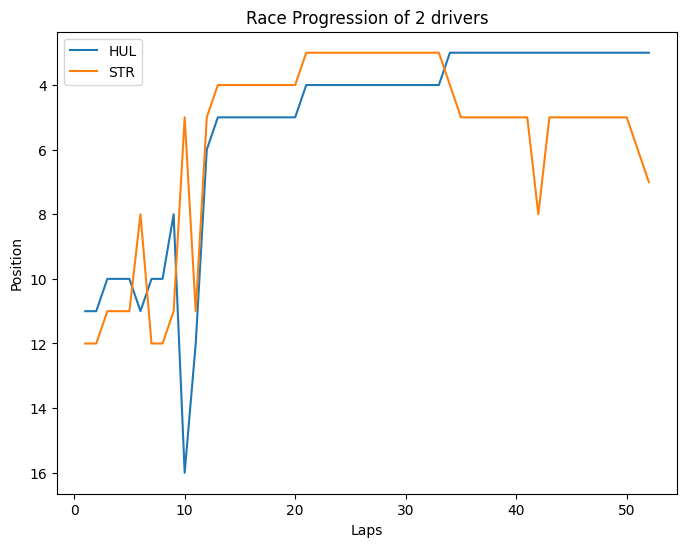

In [23]:
# Plot showing the 2 Contenders
slplot.plot_race_progression([hul,stro])

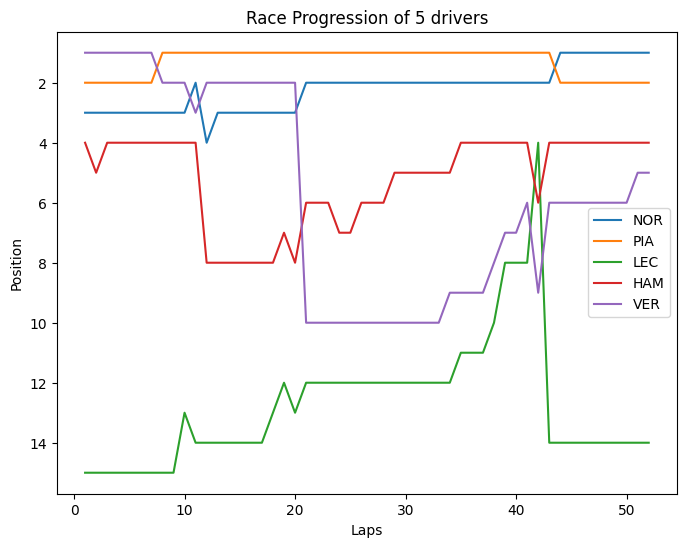

In [24]:
# Plots showing The Top grid
slplot.plot_race_progression([nor,pia,lec,ham,ver])